#Install

In [ ]:
!pip -q uninstall -y transformers huggingface_hub accelerate peft safetensors pillow tokenizers

!pip -q install --no-cache-dir \
  "huggingface_hub==0.36.2" \
  "transformers==4.57.1" \
  "tokenizers==0.22.1" \
  "accelerate==1.5.2" \
  "peft==0.12.0" \
  "safetensors==0.8.0" \
  "pillow==11.1.0" \
  "decord==0.6.0" \
  "lmdb==1.7.5" \
  "einops" \
  "timm" \
  "opencv-python-headless==4.11.0.86"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 181.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 177.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 230.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 251.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 142.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 239.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 189.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 258.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 290.3 MB/s eta 0:00:00


In [ ]:
import torch
import PIL
import huggingface_hub
import transformers

from PIL import Image, ImageDraw
from huggingface_hub import snapshot_download

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)
print("Pillow:", PIL.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("transformers:", transformers.__version__)
print("OK")

torch: 2.11.0+cu128
cuda: True
gpu: Tesla T4
Pillow: 11.3.0
huggingface_hub: 0.36.2
transformers: 4.57.1
OK


# Login HF

In [ ]:
from huggingface_hub import login

login()

# Imports + Config

In [ ]:
import gc
import re
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image, ImageDraw
from huggingface_hub import snapshot_download
from safetensors.torch import load_file
from transformers import AutoModel, AutoProcessor, AutoTokenizer

BASE_REPO = "nvidia/LocateAnything-3B"
BASE_REVISION = "c32291ca5e996f5a7a485845b4f57a233936bba0"

MODEL_REPOS = {
    "base": None,
    "random_ft": "thanhhoangnvbg/viground-random-ft-locany",
    "hardpair_ft": "thanhhoangnvbg/viground-hardpair-ft-locany",
}

PROMPT_TEMPLATE = "Locate a single instance that matches the following description: {}."
MAX_NEW_TOKENS = 128
GENERATION_MODE = "hybrid"
DO_SAMPLE = False

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16
print("device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

device: cuda
GPU: Tesla T4


# Path + Load model

In [ ]:
def patch_lora_targets(local_dir):
    local_dir = Path(local_dir)
    pattern = re.compile(
        r"target_modules=\[\s*['\"]self_attn\.q_proj['\"],\s*['\"]self_attn\.k_proj['\"],\s*['\"]self_attn\.v_proj['\"],\s*['\"]self_attn\.o_proj['\"],\s*['\"]mlp\.gate_proj['\"],\s*['\"]mlp\.down_proj['\"],\s*['\"]mlp\.up_proj['\"]\s*\]",
        flags=re.S,
    )
    replacement = "target_modules=['self_attn.q_proj', 'self_attn.k_proj', 'self_attn.v_proj', 'self_attn.o_proj']"

    changed = 0
    for p in local_dir.glob("**/modeling_locateanything.py"):
        text = p.read_text(errors="ignore")
        new_text, n = pattern.subn(replacement, text, count=1)
        if n:
            p.write_text(new_text)
            changed += n
    print("patched lora target files:", changed)


def remap_lora_checkpoint_keys_for_loaded_model(state, model):
    model_keys = set(model.state_dict().keys())
    remapped = {}
    lora_total = 0
    before = 0
    after = 0

    for key, value in state.items():
        new_key = key
        if "lora_" in key:
            lora_total += 1
            if key in model_keys:
                before += 1
            else:
                candidate = key.replace(
                    "language_model.base_model.model.",
                    "language_model.base_model.model.base_model.model.",
                    1,
                )
                if candidate in model_keys:
                    new_key = candidate

        if "lora_" in new_key and new_key in model_keys:
            after += 1
        remapped[new_key] = value

    print(f"LoRA key matches before remap: {before}/{lora_total}")
    print(f"LoRA key matches after remap: {after}/{lora_total}")
    return remapped


def load_checkpoint_state(checkpoint_dir):
    checkpoint_dir = Path(checkpoint_dir)
    state = {}
    shards = sorted(checkpoint_dir.glob("*.safetensors"))
    if not shards:
        raise FileNotFoundError(f"No root *.safetensors found in {checkpoint_dir}")

    for shard in shards:
        print("loading shard:", shard.name)
        state.update(load_file(str(shard), device="cpu"))
    return state


def load_locany_model(model_key):
    print("\n=== loading", model_key, "===")

    base_dir = snapshot_download(
        BASE_REPO,
        revision=BASE_REVISION,
        local_dir="/content/models/base_locateanything_3b",
    )
    patch_lora_targets(base_dir)

    tokenizer = AutoTokenizer.from_pretrained(base_dir, trust_remote_code=True)
    processor = AutoProcessor.from_pretrained(base_dir, trust_remote_code=True)

    model = AutoModel.from_pretrained(
        base_dir,
        torch_dtype=torch.float16,
        trust_remote_code=True,
        low_cpu_mem_usage=True,
        device_map="auto",
        max_memory={0: "12GiB", "cpu": "35GiB"},
        offload_folder="/content/offload",
    )

    if model_key != "base":
        ft_repo = MODEL_REPOS[model_key]
        ft_dir = snapshot_download(
            ft_repo,
            local_dir=f"/content/models/{model_key}",
        )

        model.wrap_llm_lora(r=8, lora_alpha=16, lora_dropout=0.05)
        state = load_checkpoint_state(ft_dir)
        state = remap_lora_checkpoint_keys_for_loaded_model(state, model)
        missing, unexpected = model.load_state_dict(state, strict=False)
        print("missing keys:", len(missing))
        print("unexpected keys:", len(unexpected))

    model.eval()
    return tokenizer, processor, model


def unload_model(tokenizer=None, processor=None, model=None):
    del tokenizer, processor, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Predict + parse bbox

In [ ]:
def build_prompt(query):
    return PROMPT_TEMPLATE.format(query)


def extract_answer(tokenizer, response):
    candidate = response[0] if isinstance(response, tuple) else response
    if isinstance(candidate, str):
        return candidate
    if isinstance(candidate, (list, tuple)):
        if not candidate:
            return ""
        if isinstance(candidate[0], str):
            return candidate[0]
        candidate = candidate[0]
    if torch.is_tensor(candidate):
        if candidate.ndim == 1:
            candidate = candidate.unsqueeze(0)
        return tokenizer.batch_decode(candidate, skip_special_tokens=False)[0]
    return str(candidate)


@torch.inference_mode()
def predict_one(tokenizer, processor, model, image, query):
    image = image.convert("RGB")
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": build_prompt(query)},
        ],
    }]

    text = processor.py_apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    images, videos = processor.process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=images,
        videos=videos,
        return_tensors="pt",
    )

    inputs = {
        k: (v.to("cuda") if torch.is_tensor(v) else v)
        for k, v in inputs.items()
    }

    response = model.generate(
        pixel_values=inputs["pixel_values"].to(dtype),
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        image_grid_hws=inputs.get("image_grid_hws", None),
        tokenizer=tokenizer,
        max_new_tokens=MAX_NEW_TOKENS,
        use_cache=True,
        generation_mode=GENERATION_MODE,
        do_sample=DO_SAMPLE,
        verbose=False,
    )
    return extract_answer(tokenizer, response)


def parse_box(answer, image_width, image_height):
    nums = re.findall(r"<box>\s*<([+-]?\d+(?:\.\d+)?)><([+-]?\d+(?:\.\d+)?)><([+-]?\d+(?:\.\d+)?)><([+-]?\d+(?:\.\d+)?)>\s*</box>", answer)
    if not nums:
        nums = re.findall(r"<box>\s*\(?\s*([+-]?\d+(?:\.\d+)?)\s*,\s*([+-]?\d+(?:\.\d+)?)\s*,\s*([+-]?\d+(?:\.\d+)?)\s*,\s*([+-]?\d+(?:\.\d+)?)\s*\)?\s*</box>", answer)

    if not nums:
        return None

    x1, y1, x2, y2 = map(float, nums[0])
    x1 = int(round(x1 / 1000 * image_width))
    y1 = int(round(y1 / 1000 * image_height))
    x2 = int(round(x2 / 1000 * image_width))
    y2 = int(round(y2 / 1000 * image_height))
    return [x1, y1, x2, y2]


def draw_box(image, box, title):
    img = image.convert("RGB").copy()
    draw = ImageDraw.Draw(img)
    if box:
        draw.rectangle(box, outline="red", width=5)
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

# Upload ảnh

Saving tu-truyen-nguoi-noi-tieng-_701665694876.jpg to tu-truyen-nguoi-noi-tieng-_701665694876.jpg


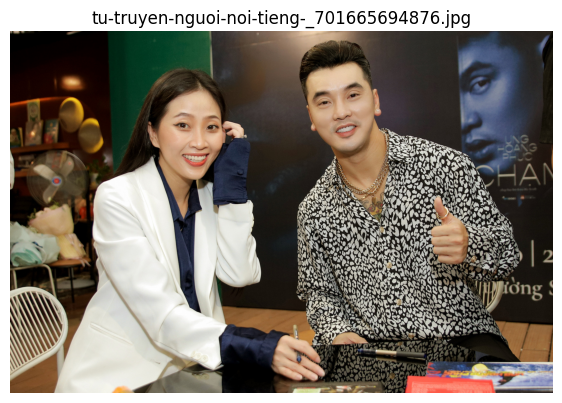

In [ ]:
from google.colab import files

uploaded = files.upload()
image_path = next(iter(uploaded.keys()))

image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.axis("off")
plt.title(image_path)
plt.show()

In [ ]:
def resize_for_inference(img, max_side=384):
    img = img.convert("RGB")
    w, h = img.size
    scale = min(1.0, max_side / max(w, h))
    new_size = (int(w * scale), int(h * scale))
    return img.resize(new_size), scale

image_infer, image_scale = resize_for_inference(image, max_side=640)

print("original:", image.size)
print("inference:", image_infer.size)

original: (2000, 1333)
inference: (640, 426)


# Nhập câu hỏi

In [ ]:
QUERY = "người mặc áo trắng"
print("Query:", QUERY)

Query: người áo trắng bên trái


In [ ]:
import gc, torch

for name in ["model", "tokenizer", "processor"]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()
print("VRAM cleaned")

VRAM cleaned


# Chạy inference 3 model


START base

=== loading base ===


Fetching 47 files:   0%|          | 0/47 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

all_results.json:   0%|          | 0.00/247 [00:00<?, ?B/s]

LICENSE: 0.00B [00:00, ?B/s]

...

patched lora target files: 1


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!
Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If y

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/root/.cache/huggingface/modules/transformers_modules/base_locateanything_3b/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))


base
raw: <ref>ng áo trắng bên trái</ref><box><81><101><581><998></box><|im_end|>
box: [162, 135, 1162, 1330]


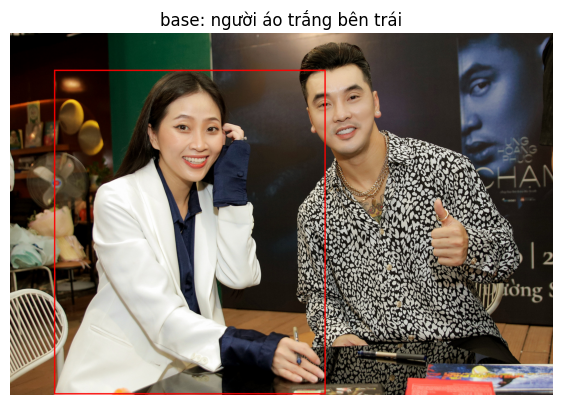


START random_ft

=== loading random_ft ===


Fetching 47 files:   0%|          | 0/47 [00:00<?, ?it/s]

modeling_locateanything.py: 0.00B [00:00, ?B/s]

patched lora target files: 1


Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


...

generation_config.json:   0%|          | 0.00/143 [00:00<?, ?B/s]

image_processing_locateanything.py: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

checkpoint-500/model-00001-of-00002.safe(…):   0%|          | 0.00/4.97G [00:00<?, ?B/s]

checkpoint-500/model-00002-of-00002.safe(…):   0%|          | 0.00/2.08G [00:00<?, ?B/s]

In [ ]:
import gc
import torch

results = {}

for model_key in ["base", "random_ft", "hardpair_ft"]:
    print("\n" + "=" * 80)
    print("START", model_key)

    # clean before loading next model
    if "model" in globals():
        del model
    if "tokenizer" in globals():
        del tokenizer
    if "processor" in globals():
        del processor
    gc.collect()
    torch.cuda.empty_cache()

    tokenizer, processor, model = load_locany_model(model_key)

    answer = predict_one(tokenizer, processor, model, image_infer, QUERY)
    box = parse_box(answer, image.width, image.height)

    results[model_key] = {
        "answer": answer,
        "box": box,
    }

    print(model_key)
    print("raw:", answer)
    print("box:", box)

    draw_box(image, box, f"{model_key}: {QUERY}")

    # important: delete current model before next iteration
    del model
    del tokenizer
    del processor
    gc.collect()
    torch.cuda.empty_cache()

print("DONE")

# Bảng so sánh raw output

In [ ]:
import pandas as pd

df = pd.DataFrame([
    {
        "model": model_key,
        "box": result["box"],
        "raw": result["answer"],
    }
    for model_key, result in results.items()
])

df

# Overlay 3 box trên cùng ảnh

In [ ]:
colors = {
    "base": "red",
    "random_ft": "blue",
    "hardpair_ft": "lime",
}

img = image.convert("RGB").copy()
draw = ImageDraw.Draw(img)

for model_key, result in results.items():
    box = result["box"]
    if box:
        draw.rectangle(box, outline=colors[model_key], width=5)
        draw.text((box[0], max(0, box[1] - 20)), model_key, fill=colors[model_key])

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title(f"Comparison: {QUERY}")
plt.show()